## 402 Project 1

In [10]:
%pip install pandas
%pip install numpy
%pip install matplotlib
%pip install scikit-learn
%pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip in

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

random_seed = 42
df = pd.read_csv("retail_trader_master.csv")
df=df.sample(n=1000, random_state=random_seed)


In [49]:
display(df.head())
display(df.isnull().sum())
display(df.duplicated().sum())

,trader_id,age,prior_experience_years,starting_capital,account_age_months,instrument,market_regime,broker_cost_bps,risk_per_trade_pct,avg_leverage,...,diversification,journals_trades,revenge_trading,overconfidence,follows_plan,chases_volatility,position_sizing_discipline,net_return_pct,profitable,blew_up
33553,TRD033553,50,0.3,12340.0,14,stocks,choppy,23.7,2.22,1.0,...,5.7,2,9.1,5.4,4.1,7.8,7.0,-40.0,0,1
9427,TRD009427,35,4.5,6980.0,13,stocks,bear,12.4,2.83,1.8,...,3.9,1,4.7,4.2,3.8,9.5,8.5,-3.8,0,0
199,TRD000199,39,1.0,4440.0,12,forex,bull,6.0,0.36,6.1,...,3.3,1,6.0,5.7,5.2,8.0,8.9,-40.0,0,1
12447,TRD012447,52,2.9,6400.0,24,futures,choppy,15.8,2.01,10.8,...,3.0,0,8.3,3.4,0.0,7.8,5.8,1.8,1,0
39489,TRD039489,40,2.9,26250.0,5,crypto,bull,14.4,0.81,3.0,...,2.3,2,8.9,4.3,5.3,7.0,8.0,17.1,1,0


trader_id                     0
age                           0
prior_experience_years        0
starting_capital              0
account_age_months            0
instrument                    0
market_regime                 0
broker_cost_bps               0
risk_per_trade_pct            0
avg_leverage                  0
trades_per_month              0
uses_stop_loss                0
avg_win_hold_days             0
avg_loss_hold_days            0
diversification               0
journals_trades               0
revenge_trading               0
overconfidence                0
follows_plan                  0
chases_volatility             0
position_sizing_discipline    0
net_return_pct                0
profitable                    0
blew_up                       0
dtype: int64

np.int64(0)

In [50]:
display(df.describe())
display(df.info())

,age,prior_experience_years,starting_capital,account_age_months,broker_cost_bps,risk_per_trade_pct,avg_leverage,trades_per_month,uses_stop_loss,avg_win_hold_days,...,diversification,journals_trades,revenge_trading,overconfidence,follows_plan,chases_volatility,position_sizing_discipline,net_return_pct,profitable,blew_up
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.00000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,34.717000,2.243400,9292.600000,16.32300,11.76640,2.26821,6.191400,32.287000,0.492000,6.616200,...,4.073700,0.603000,5.063700,4.929000,5.365600,6.768900,7.413800,-21.354900,0.181000,0.448000
std,9.894484,1.920355,11651.220192,13.08885,8.09404,1.64651,5.791691,23.686699,0.500186,5.312489,...,2.023772,0.745618,2.264416,2.235504,2.262042,2.146894,2.117525,19.586417,0.385211,0.497537
min,18.000000,0.000000,200.000000,1.00000,0.50000,0.10000,1.000000,1.000000,0.000000,0.100000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,-55.800000,0.000000,0.000000
25%,27.000000,0.900000,2700.000000,7.00000,5.70000,1.11750,1.600000,14.750000,0.000000,2.775000,...,2.675000,0.000000,3.575000,3.400000,3.900000,5.200000,5.900000,-40.000000,0.000000,0.000000
50%,35.000000,1.700000,5475.000000,13.00000,10.10000,1.88000,4.200000,27.000000,0.000000,5.450000,...,4.100000,0.000000,4.900000,5.000000,5.400000,6.800000,7.600000,-24.200000,0.000000,0.000000
75%,41.250000,3.025000,11092.500000,23.00000,15.70000,2.95500,9.500000,44.000000,1.000000,9.025000,...,5.425000,1.000000,6.600000,6.500000,6.900000,8.400000,9.300000,-4.600000,0.000000,1.000000
max,70.000000,13.400000,130530.000000,95.00000,48.10000,12.05000,44.400000,145.000000,1.000000,45.100000,...,10.000000,2.000000,10.000000,10.000000,10.000000,10.000000,10.000000,34.600000,1.000000,1.000000


<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 33553 to 13664
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   trader_id                   1000 non-null   object 
 1   age                         1000 non-null   int64  
 2   prior_experience_years      1000 non-null   float64
 3   starting_capital            1000 non-null   float64
 4   account_age_months          1000 non-null   int64  
 5   instrument                  1000 non-null   object 
 6   market_regime               1000 non-null   object 
 7   broker_cost_bps             1000 non-null   float64
 8   risk_per_trade_pct          1000 non-null   float64
 9   avg_leverage                1000 non-null   float64
 10  trades_per_month            1000 non-null   int64  
 11  uses_stop_loss              1000 non-null   int64  
 12  avg_win_hold_days           1000 non-null   float64
 13  avg_loss_hold_days          1000 

None

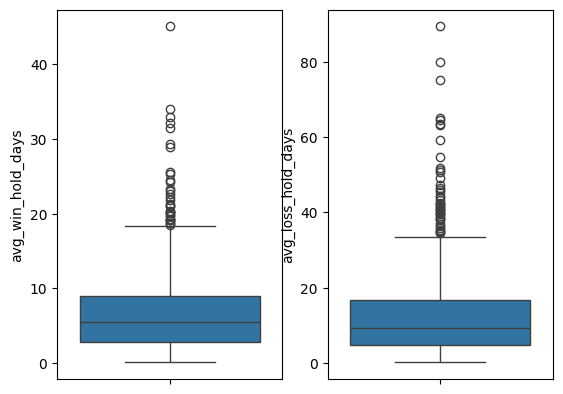

In [51]:


plt.subplot(1, 2, 1)
win=sns.boxplot(data=df, y='avg_win_hold_days')
plt.subplot(1, 2, 2)
loss=sns.boxplot(data=df, y='avg_loss_hold_days')

<Axes: xlabel='trades_per_month', ylabel='Count'>

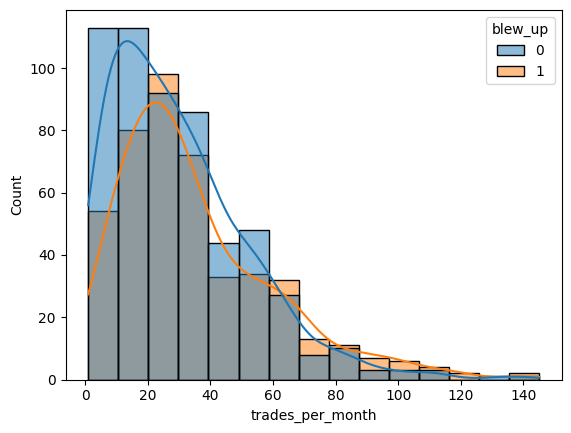

In [52]:
sns.histplot(data=df, hue='blew_up', x='trades_per_month', bins=15, kde=True)

<Axes: xlabel='revenge_trading', ylabel='net_return_pct'>

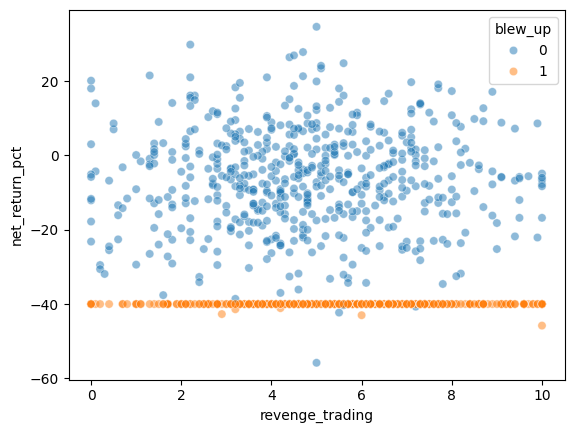

In [55]:
sns.scatterplot(data=df, x='revenge_trading', y='net_return_pct', alpha=0.5, hue='blew_up')

<Axes: xlabel='revenge_trading', ylabel='Density'>

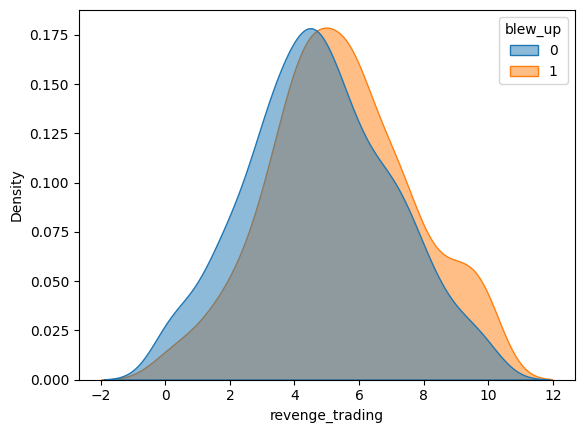

In [56]:
sns.kdeplot(data=df, x='revenge_trading', hue='blew_up', fill=True, common_norm=False, alpha=0.5)